In [1]:
! mkdir -p ../figures

In [14]:
!pip3 install --user matplotlib==3.4.2

     |████████████████████████████████| 10.3 MB 4.8 MB/s eta 0:00:01
ERROR: After October 2020 you may experience errors when installing or updating packages. This is because pip will change the way that it resolves dependency conflicts.

We recommend you use --use-feature=2020-resolver to test your packages with the new resolver before it becomes the default.

pyinterpolate 0.2.3 requires matplotlib==3.2.1, but you'll have matplotlib 3.4.2 which is incompatible.


In [1]:
import matplotlib
matplotlib.__version__

'3.4.2'

In [15]:
!pip3 install --user seaborn==0.11.1

     |████████████████████████████████| 285 kB 4.8 MB/s eta 0:00:01


In [2]:
import numpy as np
import cf_xarray # gives the ds.cf and da.cf objects
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from cmocean.tools import crop_by_percent
import gsw
import xgcm

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import seaborn as sns

In [3]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=1, memory_limit='auto')
client

/opt/tljh/user/lib/python3.7/site-packages/distributed/node.py:155: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34739 instead
  http_address["port"], self.http_server.port


Client Scheduler: tcp://127.0.0.1:42489 Dashboard: http://127.0.0.1:34739/status,Cluster Workers: 4 Cores: 4 Memory: 16.75 GB


# Open data and create grid

In [4]:
from pathlib import Path
datadir = Path('../data/processed/')
datadirraw = Path('../data/raw/interp_monthly/')

In [5]:
def preprocess(ds):
    if 'Z' in ds.variables:
        ds['Z'] = - ds.Z
        ds = ds.rename({'Z':'depth'})
    return ds

ds = xr.open_mfdataset([*datadirraw.glob('**/MXLDEPTH/*.nc'), *datadir.glob('*.nc')], preprocess=preprocess)
ds

<xarray.Dataset>
Dimensions:            (depth_left: 50, i: 720, j: 360, k: 50, nv: 2, time: 252, year: 21)
Coordinates:
    dzc                (depth_left) float32 dask.array<chunksize=(50,), meta=np.ndarray>
    dzt                (k) float32 dask.array<chunksize=(50,), meta=np.ndarray>
  * depth_left         (depth_left) float32 0.0 10.0 20.0 ... 5250.25 5683.75
  * k                  (k) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
    depth              (k) float32 dask.array<chunksize=(50,), meta=np.ndarray>
    longitude          (i) float64 dask.array<chunksize=(720,), meta=np.ndarray>
    latitude           (j) float64 dask.array<chunksize=(360,), meta=np.ndarray>
  * i                  (i) int64 0 1 2 3 4 5 6 7 ... 713 714 715 716 717 718 719
  * j                  (j) int64 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * time               (time) datetime64[ns] 1997-01-16T12:00:00 ... 2017-12-16
    timestep           (time) int64 dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds          (time, nv) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
    phi_dep_mld_t      int64 ...
  * year               (year) int64 1997 1998 1999 2000 ... 2014 2015 2016 2017
Dimensions without coordinates: nv
Data variables:
    MXLDEPTH           (time, j, i) float64 dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    SCI_mean           (year, j, i) float64 dask.array<chunksize=(21, 360, 720), meta=np.ndarray>
    alpha_mixed_layer  (j, i) float64 dask.array<chunksize=(360, 720), meta=np.ndarray>
    alpha_surface      (j, i) float64 dask.array<chunksize=(360, 720), meta=np.ndarray>
Attributes:
    product_time_coverage_start:  1992-01-01T12:00:00
    author:                       Ou Wang and Ian Fenty
    Insitution:                   JPL
    product_version:              ECCO Version 4 Release 4
    time_units:                   days since 1992-01-01 00:00:00
    Conventions:                  CF-1.6
    Project:                      Estimating the Circulation and Climate of t...
    cdm_data_type:                Grid
    geospatial_lon_units:         degrees_east
    Metadata_Conventions:         CF-1.6, Unidata Dataset Discovery v1.0, GDS...
    no_data:                      NaNf
    geospatial_lat_units:         degrees_north
    product_time_coverage_end:    2017-12-31T12:00:00
    geospatial_vertical_min:      0
    nz:                           1
    geospatial_vertical_units:    meter
    geospatial_vertical_max:      0
    date_created:                 Thu Aug 22 18:03:14 2019
    time_coverage_start:          2013-02-01T00:00:00
    time_coverage_end:            2013-03-01T00:00:00

In [6]:
palette = 'colorblind'
#sns.set_palette(palette)
sns.color_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

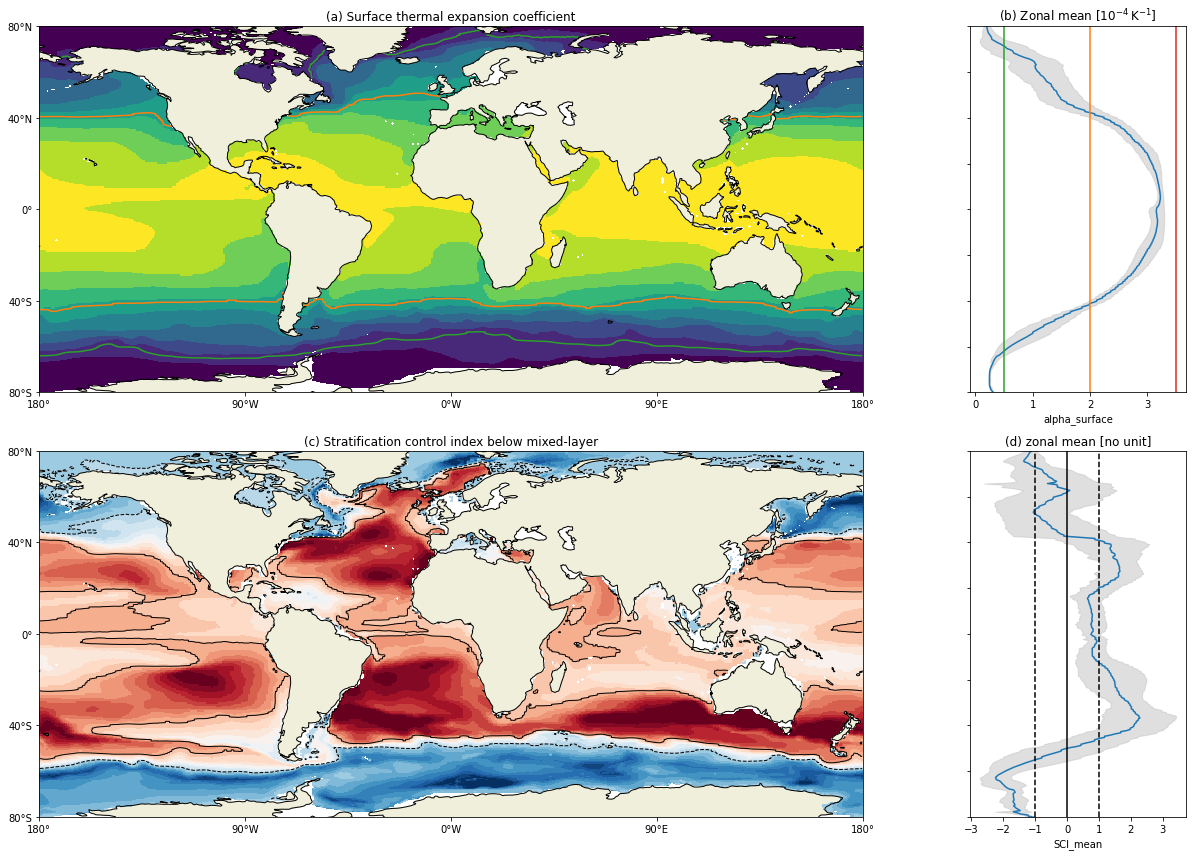

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18,12), gridspec_kw={"width_ratios":[1, .20]})

projection = ccrs.PlateCarree()

axes[0,0].remove()
fig.add_subplot(2,2,1, projection=projection)
axes[0,1].remove()
fig.add_subplot(2,2,2)
axes[1,0].remove()
fig.add_subplot(2,2,3, projection=projection)
axes[1,1].remove()
fig.add_subplot(2,2,4)

axes = fig.axes

mask = ds.MXLDEPTH.max('time')>0

###############
# TEC surface #
###############
p = (ds.alpha_surface * 1e4).where(mask).plot.contourf(
    x='longitude', y='latitude', ax=axes[0], transform=ccrs.PlateCarree(), levels=np.linspace(0,3.5,11), cmap='viridis',
    add_colorbar=False
)
levels_tec = [0.5, 2, 3.5]
colors_tec = ['C2', 'C1', 'C3']
(ds.alpha_surface * 1e4).where(mask).plot.contour(
    x='longitude', y='latitude', ax=axes[0], transform=ccrs.PlateCarree(), levels=levels_tec, colors=colors_tec
)
axes[0].add_feature(cfeature.LAND)
axes[0].coastlines()

##################
# TEC zonal mean #
##################
axes[1].fill_betweenx(
    ds.latitude,
    (ds.alpha_surface * 1e4).where(mask).mean('i') - (ds.alpha_surface * 1e4).where(mask).std('i'),
    (ds.alpha_surface * 1e4).where(mask).mean('i') + (ds.alpha_surface * 1e4).where(mask).std('i'),
    color='silver', alpha=.5
)
(ds.alpha_surface * 1e4).where(mask).mean('i').plot.line(y='latitude', ax=axes[1])
for (x, c) in zip(levels_tec, colors_tec):
    axes[1].axvline(x, color=c)

###############
# SCI surface #
###############
p = ds.SCI_mean.mean('year').where(mask).plot.contourf(
    x='longitude', y='latitude', ax=axes[2], transform=ccrs.PlateCarree(),
    cmap='RdBu_r', levels=np.linspace(-3,3,25),
    add_colorbar=False
)
ds.SCI_mean.mean('year').where(mask).plot.contour(
    x='longitude', y='latitude', ax=axes[2], transform=ccrs.PlateCarree(),
    levels=[-1,1], colors='k', linewidths=1
)
#axes[0].set_global()
axes[2].add_feature(cfeature.LAND)
axes[2].coastlines()

##################
# SCI zonal mean #
##################
axes[3].fill_betweenx(
    ds.latitude,
    ds.SCI_mean.mean('year').where(mask).mean('i') - ds.SCI_mean.mean('year').where(mask).std('i'),
    ds.SCI_mean.mean('year').where(mask).mean('i') + ds.SCI_mean.mean('year').where(mask).std('i'),
    color='silver', alpha=.5
)
ds.SCI_mean.mean('year').where(mask).mean('i').plot.line(y='latitude', ax=axes[3])
for (x, ls) in zip([-1,0,1], ['dashed', 'solid', 'dashed']):
    axes[3].axvline(x, linestyle=ls, color='k')

########################
# legends, titles, etc #
########################
for axe in axes:
    axe.set_ylim(-80, 80)

axes[0].set_title('(a) Surface thermal expansion coefficient')
axes[1].set_title(r'(b) Zonal mean [$10^{-4}\,$K$^{-1}$]')
axes[2].set_title('(c) Stratification control index below mixed-layer')
axes[3].set_title("(d) zonal mean [no unit]")

for axe in [axes[0], axes[2]]:
    axe.set_xticks(np.linspace(-180, 180, 5), crs=projection)
    axe.set_yticks(np.linspace(-80, 80, 5), crs=projection)
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    axe.xaxis.set_major_formatter(lon_formatter)
    axe.yaxis.set_major_formatter(lat_formatter)
    axe.set_xlabel('')
    axe.set_ylabel('')

for axe in [axes[1], axes[3]]:
    axe.set_yticks(np.linspace(-80, 80, 9))
    axe.set_yticklabels([])
    axe.set_ylabel('')
    
fig.tight_layout()
fig.savefig('../figures/figure_2_ecco.pdf', transparent=True, bbox_inches='tight', pad_inches=0.1)